# 02. Feature Engineering

Day 1 EDA에서 얻은 근거로 피처를 만들고 고르는 단계입니다. 원칙은 두 가지입니다.

- **cycle 100 이내 데이터만 사용합니다.** Knee, `cycle / cycle_life`처럼 수명을 알아야 계산되는 값은 쓰지 않아 타깃 누수를 막습니다.
- **배치가 바뀌어도 관계가 유지되는 피처를 우선합니다.** Batch 1로 학습해 Batch 2, 3을 맞혀야 하기 때문입니다.

구성: 1. 재현성 점검 → 2. 피처 선별 기준 → 3. 배치 간 값 범위 이동

In [1]:
import sys, warnings; warnings.filterwarnings("ignore")
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))      # 저장소 루트를 경로에 추가 (src/ 임포트용)

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import display

# 그래프 공통 스타일 (그림 안 글자는 폰트 의존을 피하려고 영문으로 작성)
plt.rcParams.update({"axes.unicode_minus": False, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": "#e6e5e0", "figure.dpi": 110})
pd.set_option("display.width", 200); pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

ROOT = Path.cwd().parent                         # 저장소 루트
FIG = ROOT / "results" / "figures"               # 그림 저장 위치

## 1. 재현성 점검

원본 `.mat` 캐시에서 정제와 피처 생성을 처음부터 다시 돌려, 저장해 둔 `data/features_cell_level.csv`와 같은 결과가 나오는지 확인합니다. 정제는 단계별로 셀을 줄여 가므로 단계마다 몇 셀이 남는지도 함께 봅니다.

In [2]:
from src.preprocess import load_cells, clean_cells
from src.features import build_features

feat_csv = pd.read_csv(ROOT / "data" / "features_cell_level.csv")
cache = ROOT.parent / "cache" / "cells_extracted.pkl"      # 저장소 밖에 둔 추출 캐시 (용량 때문에 git 제외)

if cache.exists():
    cells = load_cells(ROOT.parent / "archive", cache)
    cells, SUMMARY, meta, attr, merges = clean_cells(cells, verbose=False)
    new = build_features(cells, SUMMARY, meta).set_index("cell_id").sort_index()
    old = feat_csv.set_index("cell_id").sort_index()
    diff = np.nanmax(np.abs(new[old.columns].values.astype(float) - old.values.astype(float)))
    print(f"셀 수 {len(new)} | 저장된 CSV 와의 최대 절대 차이 {diff:.1e}")
    display(attr)                                                                   # 정제 단계별 남은 셀 수
    display(merges[["b1", "b2", "policy_b1", "policy_b2", "b2_cycles", "published_add", "verified", "merged"]])
else:
    print("캐시가 없어 저장된 CSV 로 진행합니다. python -m src.features 로 다시 만들 수 있습니다.")
print("배치별 셀 수:", feat_csv.groupby("batch").size().to_dict())

[cache] /sessions/rcw-01eubbmx1xi2ggweuu9aknrq/mnt/Mini project/cache/cells_extracted.pkl 로드


셀 수 115 | 저장된 CSV 와의 최대 절대 차이 7.1e-15


,0. 추출 직후,1. life 결측 제거,2. 이어측정 병합,4. 논문 제거 목록,4b. EOL 미도달(마지막 용량>0.90Ah),5. 초기윈도우 무결성
1,46,46,46,41,36,36
2,47,39,39,39,39,39
3,46,44,44,40,40,40
합계,139,129,129,120,115,115


,b1,b2,policy_b1,policy_b2,b2_cycles,published_add,verified,merged
0,b1c0,b2c7,3.6C(80%)-3.6C,4.8C(80%)-4.8C-newstructure,806,662,False,False
1,b1c1,b2c8,3.6C(80%)-3.6C,5.2C(58%)-4C-newstructure,947,981,False,False
2,b1c2,b2c9,3.6C(80%)-3.6C,5.6C(26%)-4.5C-newstructure,819,1060,False,False
3,b1c3,b2c15,4C(80%)-4C,3.6C(9%)-5C,414,208,False,False
4,b1c4,b2c16,4C(80%)-4C,4.8C(80%)-4.8C,499,482,False,False


배치별 셀 수: {1: 36, 2: 39, 3: 40}


최대 차이가 거의 0이므로 CSV는 원본에서 그대로 재현됩니다. 정제 표에서 눈여겨볼 두 가지가 있습니다.

- **병합 5쌍이 모두 검증 실패입니다.** 논문은 Batch 1의 미완료 셀 5개를 이어 측정한 셀과 합쳐 수명을 보정하는데, 우리 Batch 2 파일은 사이클 수가 논문 값과 달라 같은 셀로 볼 근거가 없었습니다. 맞지 않는 데이터를 억지로 합치는 것보다 병합하지 않는 쪽을 택했습니다.
- **그래서 `4b` 단계에서 Batch 1의 5셀(b1c0∼c4)을 추가로 제거했습니다.** 이 셀들은 측정이 끝난 시점에도 용량이 0.97∼1.04Ah로 EOL(0.88Ah)에 닿지 않았는데, 수명 라벨은 측정 종료 사이클로 들어가 있었습니다. 실제 수명보다 짧게 적힌 라벨이라 학습에서 뺐습니다.

## 2. 피처 선별 기준

| 구분 | 피처 | 판단 근거 |
|---|---|---|
| 핵심 | `dq_log_var` | 수명과 상관이 가장 높고(r ≈ −0.85) 세 배치에서 방향이 같으며, ΔQ(V) 곡선의 변동성이라는 물리적 의미가 분명함 |
| ΔQ 형태 | `dq_log_abs_min`, `dq_skew`, `dq_kurt` | 분산이 담지 못하는 곡선 모양 정보를 보완 |
| 초기 용량 | `QD_2`, `QD_max_minus_2` | 논문 Discharge 모델의 피처이지만 배치 간 값 범위 이동이 큼 (3절) |
| 운전·상태 | `chargetime_avg_2_6`, `Tavg_mean_2_100`, `IR_min_2_100` | ΔQ가 못 설명하는 부분을 보완할 후보. 배치마다 부호가 뒤집힐 위험 |
| 제외 | `QD_slope_*`, `QD_intercept_2_100`, `t80_min`, `C_avg`, newstructure 플래그, Knee 계열 | 아래 점검 결과와 공선성, 중복, 100사이클 시점에 알 수 없는 값 등 |

먼저 각 후보가 수명과 어떤 상관을 갖는지 배치별로 비교합니다. 핵심은 **세 배치에서 방향이 같은가**입니다.

,r_B1,r_B2,r_B3,세 배치 부호 일치
feature,,,,
dq_log_var,-0.844,-0.918,-0.805,O
dq_log_abs_min,-0.821,-0.901,-0.811,O
dq_skew,-0.434,-0.126,-0.291,O
dq_kurt,0.022,0.653,0.092,O
QD_2,0.152,-0.203,0.257,X
QD_max_minus_2,0.308,-0.420,0.008,X
chargetime_avg_2_6,0.575,-0.942,0.555,X
Tavg_mean_2_100,-0.156,0.393,-0.042,X
IR_min_2_100,0.345,-0.574,0.351,X


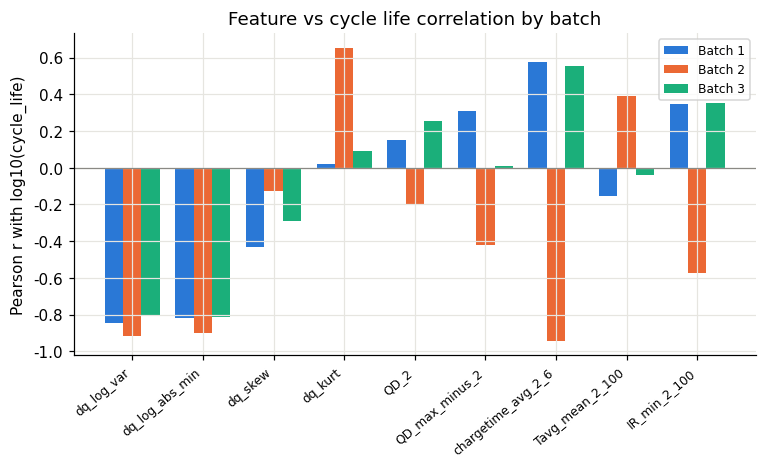

In [3]:
CAND = ["dq_log_var", "dq_log_abs_min", "dq_skew", "dq_kurt", "QD_2", "QD_max_minus_2",
        "chargetime_avg_2_6", "Tavg_mean_2_100", "IR_min_2_100"]

def corr_by_batch(cols):
    """피처 ↔ log10(수명) 상관을 배치별로 계산"""
    rows = []
    for c in cols:
        row = {"feature": c}
        for b in (1, 2, 3):
            g = feat_csv[feat_csv.batch == b].dropna(subset=[c])
            row[f"r_B{b}"] = np.corrcoef(g[c], g.log_life)[0, 1]
        rows.append(row)
    return pd.DataFrame(rows).set_index("feature")

corr_b = corr_by_batch(CAND)
same = (np.sign(corr_b.r_B1) == np.sign(corr_b.r_B2)) & (np.sign(corr_b.r_B1) == np.sign(corr_b.r_B3))
corr_b["세 배치 부호 일치"] = np.where(same, "O", "X")
display(corr_b)

fig, ax = plt.subplots(figsize=(8, 3.8)); w, x = .26, np.arange(len(CAND))
for i, (b, color) in enumerate([(1, "#2a78d6"), (2, "#eb6834"), (3, "#1baf7a")]):
    ax.bar(x + (i - 1) * w, corr_b[f"r_B{b}"], w, color=color, label=f"Batch {b}")
ax.axhline(0, color="#8a8984", lw=.8)
ax.set_xticks(x, CAND, rotation=40, ha="right", fontsize=8)
ax.set_ylabel("Pearson r with log10(cycle_life)")
ax.set_title("Feature vs cycle life correlation by batch"); ax.legend(fontsize=8)
fig.savefig(FIG / "fe_corr_by_batch.png", dpi=180, bbox_inches="tight"); plt.show()

ΔQ 계열(`dq_log_var`, `dq_log_abs_min`, `dq_skew`)은 크기는 조금씩 달라도 세 배치에서 방향이 같습니다. 반대로 충전시간, 저항, 온도, 초기 용량 계열은 **Batch 2에서만 부호가 뒤집힙니다.** Batch 1에서 배운 "이 값이 크면 수명이 길다"는 관계가 Batch 2에서는 반대로 나타난다는 뜻이라, 이런 피처는 새 배치에서 오히려 예측을 해칠 수 있습니다. (`dq_kurt`은 부호는 같지만 Batch 2에서만 r이 0.65로 유난히 커서 크기가 불안정합니다.)

### 제외한 후보 점검

용량 기울기(`QD_slope_*`)와 절편은 논문 Discharge 모델에 들어가는 피처이지만 우리는 쓰지 않았습니다. 이유가 타당한지 같은 방식으로 확인합니다.

In [4]:
EXCL = ["QD_slope_2_100", "QD_slope_91_100", "QD_intercept_2_100"]
b = {k: feat_csv[feat_csv.batch == k] for k in (1, 2, 3)}
chk = corr_by_batch(EXCL)
chk["B2 중 B1 범위 밖"] = [int(((b[2][c] < b[1][c].min()) | (b[2][c] > b[1][c].max())).sum()) for c in EXCL]
display(chk)
print("QD_intercept_2_100 과 QD_2 의 상관:", round(feat_csv.QD_intercept_2_100.corr(feat_csv.QD_2), 3))

,r_B1,r_B2,r_B3,B2 중 B1 범위 밖
feature,,,,
QD_slope_2_100,0.556,-0.373,0.431,19
QD_slope_91_100,0.535,0.303,0.464,28
QD_intercept_2_100,0.143,-0.149,0.234,17


QD_intercept_2_100 과 QD_2 의 상관: 0.997


- `QD_slope_2_100`은 Batch 2에서 부호가 뒤집힙니다. 초기 100사이클의 용량 변화가 정격의 0.15% 수준으로 아주 작아 장수명과 단수명을 가르는 힘이 약했다는 Day 1 EDA 결과와도 맞습니다.
- `QD_slope_91_100`은 부호는 일관되지만 상관이 ΔQ 계열(0.8∼0.9)보다 훨씬 약하고, Batch 2의 28/39셀이 Batch 1 값 범위 밖입니다.
- `QD_intercept_2_100`은 `QD_2`와 상관이 1.0으로 같은 정보라 중복입니다.

세 후보 모두 배치 간 일관성이나 정보량에서 이점이 없어 제외했습니다. 다만 이 판단은 별도 모델 실험으로 검증한 것이 아니라 위 상관 점검에 근거한 것입니다.

## 3. 배치 간 값 범위 이동

Batch 2 셀의 피처 값이 Batch 1이 가진 범위 밖에 얼마나 나가 있는지 셉니다. 모델은 학습 때 본 값의 범위 안에서만 믿을 만하고, 범위 밖의 값을 받으면 외삽(학습 범위 밖을 예측)이 되어 오차가 커지기 쉽습니다. 이 비교는 피처 값의 분포만 보며 Test 수명 라벨은 사용하지 않습니다.

In [5]:
b1, b2 = feat_csv[feat_csv.batch == 1], feat_csv[feat_csv.batch == 2]
use = [c for c in CAND if c != "IR_min_2_100"]
shift = pd.DataFrame({c: {"B1 min": b1[c].min(), "B1 max": b1[c].max(),
                          "B2 min": b2[c].min(), "B2 max": b2[c].max(),
                          "B2 중 B1 범위 밖": int(((b2[c] < b1[c].min()) | (b2[c] > b1[c].max())).sum())}
                      for c in use}).T
display(shift)

,B1 min,B1 max,B2 min,B2 max,B2 중 B1 범위 밖
dq_log_var,-4.179,-3.350,-4.449,-3.086,17.000
dq_log_abs_min,-1.625,-1.189,-1.718,-1.065,14.000
dq_skew,-0.595,0.242,-0.687,0.374,10.000
dq_kurt,-1.348,-1.073,-1.446,-0.764,16.000
QD_2,1.054,1.095,1.067,1.109,22.000
QD_max_minus_2,0.002,0.007,0.000,0.014,24.000
chargetime_avg_2_6,8.965,12.147,10.036,10.224,0.000
Tavg_mean_2_100,30.375,33.895,29.882,35.668,7.000


`QD_2`는 39셀 중 22셀, `QD_max_minus_2`는 24셀이 Batch 1 범위를 벗어납니다. 초기 용량은 배치(제조 로트)가 바뀌면 수준 자체가 달라진다는 뜻이고, 앞서 본 부호 뒤집힘과 같은 신호입니다. ΔQ 계열도 10∼17셀이 범위 밖이지만, 이쪽은 범위가 이동해도 수명과의 관계 방향이 유지됩니다.

최종 모델에는 이 두 초기 용량 피처가 들어 있습니다(03번 노트북). 그래서 Batch 2의 오차와 관련이 있을 수 있다는 가설을 세웠습니다. 피처를 빼고 다시 평가하면 Test를 한 번 더 보게 되므로, 모델은 그대로 두고 SHAP으로 기여도만 분해해 확인했습니다(04번 노트북). 결과는 가설이 일부만 맞았다는 것으로, Batch 2 편향의 약 5분의 1만 이 피처에서 왔습니다.